<a href="https://colab.research.google.com/github/EllieD27/carisurg-portfolio/blob/main/CariSurg%20-%20Week%200%20-%20Assignment%202%20-%20Cleaning%20Pulse%20Column.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")

FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/EmergencyTriageDataset_Reduced_Dirty.csv'

#FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

df = pd.read_csv(FILE_PATH)

# continuation from day 1
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

print(f"Dataset: {df.shape[0]} rows x {df.shape[1]} columns")




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!
Dataset: 2205 rows x 11 columns


In [ ]:
# The five most useful inspection commands
print("=== head() — first 5 rows ===")
print(df.head())

=== head() — first 5 rows ===
   ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR   Fio2
0   1   34       0  15.0   93   67.0   75.67  128.0  36.8  14.0   21.0
1   2   20       1  15.0  130   90.0  103.33   80.0  37.0  16.0   21.0
2   3   77       0  14.0  163  105.0  124.33   92.0  36.8  18.0   21.0
3   4   23       0   8.0  100   60.0   73.33  100.0  37.0  12.0  100.0
4   5   86       0  15.0  150   90.0  110.00   85.0  37.0  19.0   21.0


In [ ]:
print("=== tail() — last 5 rows (catches truncation issues) ===")
print(df.tail())

=== tail() — last 5 rows (catches truncation issues) ===
        ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR  Fio2
2200  2380   65       1  14.0  170   50.0   90.00   65.0  37.0  22.0  21.0
2201  2381   84       0  15.0  180  120.0  140.00   85.0  36.1  18.0  21.0
2202  2382   78       0  15.0  132   78.0   96.00  100.0  37.9  16.0  21.0
2203  2383   65       1  15.0  140   80.0  100.00   85.0  36.4  16.0  21.0
2204  2384   78       0  15.0  145   90.0  108.33   75.0  37.6  20.0  21.0


In [ ]:
print("=== info() — column types and non-null counts ===")
df.info()

=== info() — column types and non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      2205 non-null   int64  
 1   Age     2205 non-null   int64  
 2   Gender  2205 non-null   int64  
 3   GCS     2183 non-null   object 
 4   SBP     2205 non-null   object 
 5   DBP     2183 non-null   float64
 6   MAP     2183 non-null   float64
 7   pulse   2183 non-null   object 
 8   Temp    2183 non-null   object 
 9   RR      2183 non-null   float64
 10  Fio2    2183 non-null   float64
dtypes: float64(4), int64(3), object(4)
memory usage: 189.6+ KB


In [ ]:
print("=== describe() — statistics for numeric columns only ===")
print(df.describe())

=== describe() — statistics for numeric columns only ===
                ID          Age       Gender          DBP          MAP  \
count  2205.000000  2205.000000  2205.000000  2183.000000  2183.000000   
mean   1154.987755    61.829478     0.533333    77.479615    93.912277   
std     677.167364    18.485363     0.499001    16.713289    19.006296   
min       1.000000    18.000000     0.000000    30.000000    39.330000   
25%     577.000000    50.000000     0.000000    70.000000    82.500000   
50%    1135.000000    64.000000     1.000000    78.000000    93.330000   
75%    1703.000000    77.000000     1.000000    87.000000   103.330000   
max    2384.000000    98.000000     1.000000   173.000000   185.000000   

                RR         Fio2  
count  2183.000000  2183.000000  
mean     20.262254    25.019698  
std       5.742333    10.144288  
min      12.000000    21.000000  
25%      17.000000    21.000000  
50%      18.000000    21.000000  
75%      21.000000    21.000000  
max 

In [ ]:
# printing no. of colums and rows
print("=== shape — (rows, columns) ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

=== shape — (rows, columns) ===
Rows: 2205, Columns: 11


In [ ]:
# GCS is currently stored as a string (object type)
print("GCS dtype:", df['GCS'].dtype)
print("Unique GCS values:", df['GCS'].unique())

GCS dtype: object
Unique GCS values: ['15.0' '14.0' '8.0' '13.0' '12.0' '10.0' 'error' nan '7.0' '9.0' '11.0'
 '6.0' '3.0']


In [ ]:
# pd.to_numeric() with errors='coerce' converts numbers and turns
# everything non-numeric (like 'error') into NaN
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')

print("After conversion:")
print(f"  dtype: {df['GCS'].dtype}")
print(f"  NaN count: {df['GCS'].isnull().sum()}")
print(f"  Range: {df['GCS'].min()} to {df['GCS'].max()}")

After conversion:
  dtype: float64
  NaN count: 44
  Range: 3.0 to 15.0


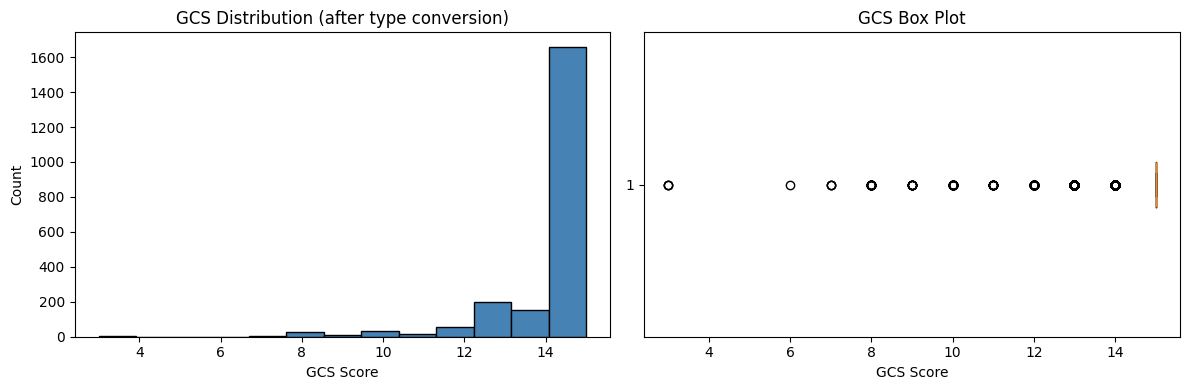


Plot saved as gcs_distribution.png


In [ ]:
# Step 1: Visualise BEFORE removing anything
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['GCS'].dropna(), bins=13, edgecolor='black', color='steelblue')
axes[0].set_xlabel('GCS Score')
axes[0].set_ylabel('Count')
axes[0].set_title('GCS Distribution (after type conversion)')

axes[1].boxplot(df['GCS'].dropna(), vert=False)
axes[1].set_xlabel('GCS Score')
axes[1].set_title('GCS Box Plot')

plt.tight_layout()
plt.savefig('gcs_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nPlot saved as gcs_distribution.png")

In [ ]:
# Step 2: Flag physiologically impossible values
# GCS valid range: 3–15
invalid_gcs = df[(df['GCS'] < 3) | (df['GCS'] > 15)]
print(f"GCS values outside valid range (3–15): {len(invalid_gcs)} rows")
print(invalid_gcs[['ID', 'GCS']].head(10))

GCS values outside valid range (3–15): 0 rows
Empty DataFrame
Columns: [ID, GCS]
Index: []


In [ ]:
# Step 3: Replace invalid values with NaN
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
print(f"NaN count after range filter: {df['GCS'].isnull().sum()}")

NaN count after range filter: 44


In [ ]:
# Computing the median and using it to fill NaN values
gcs_median = df['GCS'].median()
print(f"GCS median (before imputation): {gcs_median}")

df['GCS'] = df['GCS'].fillna(gcs_median)

print(f"GCS after imputation:")
print(df['GCS'].describe())
print(f"Remaining NaNs: {df['GCS'].isnull().sum()}")

GCS median (before imputation): 15.0
GCS after imputation:
count    2205.000000
mean       14.425850
std         1.375031
min         3.000000
25%        15.000000
50%        15.000000
75%        15.000000
max        15.000000
Name: GCS, dtype: float64
Remaining NaNs: 0


In [ ]:
# SBP = Systolic Blood Pressure. Valid range: 50–250 mmHg.
# Extremely low SBP (<70) = shock risk. Extremely high (>200) = hypertensive crisis.

print("SBP unique values (sample):", df['SBP'].unique()[:15])
print("SBP dtype:", df['SBP'].dtype)

SBP unique values (sample): ['93' '130' '163' '100' '150' '120' '110' '153' '152' '186' '107' '80'
 '75' '58' '140']
SBP dtype: object


In [ ]:
# 1. Converting to numeric
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
print("After type conversion:")
print(df['SBP'].describe())

After type conversion:
count    2183.000000
mean      128.388456
std        43.881583
min        30.000000
25%       110.000000
50%       125.000000
75%       140.000000
max       500.000000
Name: SBP, dtype: float64


In [ ]:
# 2. Identifying out-of-range values
invalid_sbp = df[(df['SBP'] < 50) | (df['SBP'] > 250)]
print(f"Out-of-range SBP rows: {len(invalid_sbp)}")
print(invalid_sbp[['ID', 'SBP']].head())

Out-of-range SBP rows: 44
      ID    SBP
29    32   30.0
111  123  500.0
168  183  500.0
231  247   30.0
275  291  500.0


In [ ]:
# 3. Replacing out-of-range with NaN, then impute with median
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
sbp_median = df['SBP'].median()
df['SBP'] = df['SBP'].fillna(sbp_median)

print(f"SBP after cleaning: min={df['SBP'].min()}, max={df['SBP'].max()}, NaNs={df['SBP'].isnull().sum()}")

SBP after cleaning: min=55.0, max=250.0, NaNs=0


In [ ]:
# Looking at temp values
print("Temp unique values (sample):")
print(df['Temp'].unique()[:20])

Temp unique values (sample):
['36.8' '37.0' '36.5' '39.0' '37.3' '36.7' '37.8' '38.5' '38.0' '37.6'
 '38.2' '37C' '36.2' '37.2' '37.5' nan '36.9' '39.6' '37.4' '50']


In [ ]:
# Standardizing everything to Celcius for Understandibility
def to_celsius(val):
    if pd.isnull(val):
        return np.nan                        # NaN -> NaN
    val_str = str(val).strip()
    try:
        if val_str.endswith('C'):
            return float(val_str[:-1])       # stripping the C at the end for uniformality
        elif val_str.endswith('F'):
            return (float(val_str[:-1]) - 32) * 5 / 9  # Fahrenheit to Celsius
        else:
            return float(val_str)            # value already in celcius
    except ValueError:
        return np.nan                        # anything else / unrecognizable -> NaN

df['Temp'] = df['Temp'].apply(to_celsius)

print("After standardisation:")
print(df['Temp'].unique()[:20])
print ("\n")
print(df['Temp'].describe())

After standardisation:
[36.8 37.  36.5 39.  37.3 36.7 37.8 38.5 38.  37.6 38.2 36.2 37.2 37.5
  nan 36.9 39.6 37.4 50.  40. ]


count    2183.000000
mean       37.323683
std         1.334411
min        35.000000
25%        37.000000
50%        37.000000
75%        37.500000
max        50.000000
Name: Temp, dtype: float64


In [ ]:
# Applying range filter: valid body temperature 32–43°C
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan

# Imputing with median
temp_median = round(df['Temp'].median(), 1)
df['Temp'] = df['Temp'].fillna(temp_median)

print(f"Temp after cleaning: min={df['Temp'].min():.1f}, max={df['Temp'].max():.1f}, NaNs={df['Temp'].isnull().sum()}")

Temp after cleaning: min=35.0, max=41.7, NaNs=0


In [ ]:
# ── PULSE GROUP PROJECT SECTION ──────────────────────────────────

COLUMN = 'pulse'
VALID_MIN = 20
VALID_MAX = 250

print(f"=== Cleaning: {COLUMN} ===")
print(f"Unique values: {df[COLUMN].unique()}")
print(f"Dtype: {df[COLUMN].dtype}")
print()

# Step 1: Converting to numeric
df[COLUMN] = pd.to_numeric(df[COLUMN], errors='coerce')
print(f"After type conversion — NaNs: {df[COLUMN].isnull().sum()}")
print(df[COLUMN].describe())

=== Cleaning: pulse ===
Unique values: ['128.0' '80.0' '92.0' '100.0' '85.0' '99.0' '78.0' '130.0' '63.0' '98.0'
 '76.0' '166.0' '151.0' '94.0' '87.0' '75.0' '88.0' '108.0' '112.0'
 '125.0' '65.0' '90.0' '300.0' '72.0' '58.0' '140.0' '105.0' '110.0'
 'error' '97.0' '82.0' '84.0' '86.0' '56.0' '70.0' '69.0' '120.0' '111.0'
 '156.0' '60.0' '95.0' '115.0' '68.0' '104.0' '109.0' '67.0' '55.0'
 '119.0' '102.0' '129.0' '118.0' '96.0' '0.0' '91.0' '122.0' '54.0'
 '114.0' '41.0' '89.0' '136.0' '79.0' '145.0' '134.0' '48.0' nan '155.0'
 '121.0' '170.0' '137.0' '101.0' '107.0' '144.0' '93.0' '106.0' '73.0'
 '77.0' '142.0' '126.0' '116.0' '50.0' '124.0' '133.0' '132.0' '74.0'
 '150.0' '139.0' '62.0' '160.0' '103.0' '52.0' '40.0' '117.0' '61.0'
 '113.0' '53.0' '83.0' '42.0' '138.0' '135.0' '66.0' '81.0' '64.0' '123.0'
 '59.0' '57.0' '49.0' '131.0' '147.0' '127.0' '71.0' '141.0' '162.0'
 '165.0' '45.0' '146.0' '51.0' '148.0']
Dtype: object

After type conversion — NaNs: 44
count    2161.000000
mean

In [ ]:
# Range filter
invalid = df[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX)]
print(f"Out-of-range values: {len(invalid)}")

df.loc[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX), COLUMN] = np.nan

# Step 3: Imputing — Median - since there are outliers in the pulse values,
#                           median would be most appropriate to impute


# Imputing with median
pulse_median = round(df[COLUMN].median(), 1)
df[COLUMN] = df[COLUMN].fillna(pulse_median)


print(f"\n=======  After cleaning Pulse Column:  =======")
print ("Median: \t", pulse_median)
print(df[COLUMN].describe())

print(f"NaNs remaining: {df[COLUMN].isnull().sum()}")

Out-of-range values: 0

=======  After cleaning Pulse Column:  =======
Median: 	 90.0
count    2205.000000
mean       94.326984
std        19.881720
min        40.000000
25%        80.000000
50%        90.000000
75%       106.000000
max       170.000000
Name: pulse, dtype: float64
NaNs remaining: 0


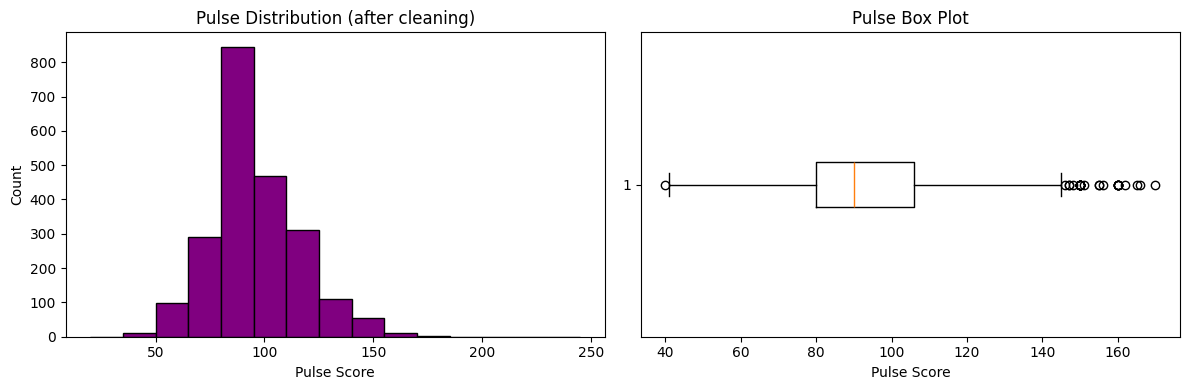


Plot saved as pulse_distribution.png


In [ ]:
# Visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['pulse'].dropna(), bins=range(20,250,15), edgecolor='black', color='purple')
axes[0].set_xlabel('Pulse Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Pulse Distribution (after cleaning)')

axes[1].boxplot(df['pulse'].dropna(), vert=False)
axes[1].set_xlabel('Pulse Score')
axes[1].set_title('Pulse Box Plot')

plt.tight_layout()
plt.savefig('pulse_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nPlot saved as pulse_distribution.png")